# 08 — Meta-Features: can we *predict* the winner?

> **The bridge from Act III to Act IV.** The reversals in notebook 07 are not
> random — they track measurable properties of the dataset. Here we test whether
> a dataset's **meta-features** (size, dimensionality, imbalance, categorical
> fraction, task type) predict *which family wins*. The splits of a tiny,
> interpretable tree become the branches of the decision flowchart in notebook
> 09 — now data-derived rather than hand-waved. This is a small meta-learning
> result.
>
> **Honesty up front:** with only 18 datasets this is **descriptive**. The tree
> has no held-out test; its job is to *illustrate* the structure, not to be a
> deployable predictor.

In [1]:
import sys; sys.path.insert(0, '..')
import os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.data.registry import load_dataset, get_all_dataset_names
from src.models.factory import get_model_family
from src.evaluation.enrichments import (
    PRIMARY, FAMILY_SHORT, bayesian_signed_rank, bayesian_pairwise_table,
    normalized_regret, family_variance_decomposition, build_meta_features,
    winning_family_table, winner_decision_tree, fold_robustness,
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})
os.makedirs('../results/figures', exist_ok=True)
FAMC = {'GBDT': '#2196F3', 'DL': '#FF9800', 'FM': '#4CAF50'}

test = pd.read_csv('../results/aggregated/test_results.csv')
FAM = {m: get_model_family(m) for m in test.model.unique()}
meta = build_meta_features(get_all_dataset_names(), load_dataset,
                           '../configs/datasets.yaml', data_dir='../data/raw')
print('loaded', test.shape, '| datasets:', meta.shape[0])

loaded (250, 16) | datasets: 18


In [2]:
W = winning_family_table(test, FAM, meta)
display(W[['winner','win_family','n','n_feat','imbalance','cat_frac','feat_types']])
print('winning-family counts:', W.win_family.value_counts().to_dict())

,winner,win_family,n,n_feat,imbalance,cat_frac,feat_types
dataset,,,,,,,
adult,tabfm,FM,48842,14,3.179173,0.571429,mixed
amazon_employee,catboost,GBDT,32769,9,16.274117,1.000000,categorical
bank_marketing,tabfm,FM,45211,16,7.548119,0.562500,mixed
california_housing,tabfm,FM,20634,8,NaN,0.000000,numerical
cardiovascular_disease,tabfm,FM,70000,11,1.001201,0.545455,mixed
covertype,tabfm,FM,581012,54,103.131052,0.814815,numerical
credit_g,ft_transformer,DL,1000,20,2.333333,0.650000,mixed
give_me_some_credit,tabfm,FM,150000,10,13.961101,0.000000,numerical
helena,tabm,DL,65196,27,36.081081,0.000000,numerical


winning-family counts: {'FM': 14, 'DL': 3, 'GBDT': 1}


## 1. Which meta-feature moves which model?

Per-model Spearman correlation between within-dataset rank and each meta-feature.
Negative = the model gets *relatively better* as that meta-feature grows.

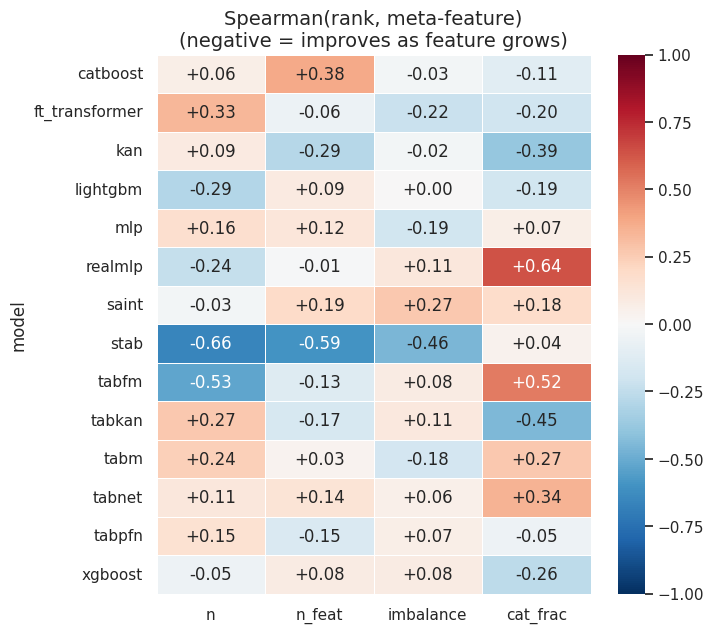

,n,n_feat,imbalance,cat_frac
model,,,,
catboost,0.06,0.38,-0.03,-0.11
ft_transformer,0.33,-0.06,-0.22,-0.20
kan,0.09,-0.29,-0.02,-0.39
lightgbm,-0.29,0.09,0.00,-0.19
mlp,0.16,0.12,-0.19,0.07
realmlp,-0.24,-0.01,0.11,0.64
saint,-0.03,0.19,0.27,0.18
stab,-0.66,-0.59,-0.46,0.04
tabfm,-0.53,-0.13,0.08,0.52


In [3]:
from scipy.stats import spearmanr
def all_ranks():
    out = []
    for ds, sub in test.groupby('dataset'):
        col, higher = PRIMARY[sub.task_type.iloc[0]]
        s = sub.dropna(subset=[col]).copy(); s['rank'] = s[col].rank(ascending=not higher)
        out.append(s[['model','dataset','rank']])
    return pd.concat(out)
R = all_ranks()
for c in ['n','n_feat','imbalance','cat_frac']:
    R[c] = R.dataset.map(meta[c])
R['imbalance'] = R['imbalance'].fillna(1.0)
rows = []
for m in sorted(test.model.unique()):
    sub = R[R.model == m]
    rows.append({'model': m, **{c: spearmanr(sub[c], sub['rank'])[0]
                                for c in ['n','n_feat','imbalance','cat_frac']}})
corr = pd.DataFrame(rows).set_index('model')
fig, ax = plt.subplots(figsize=(7,7))
sns.heatmap(corr, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=.5, ax=ax)
ax.set_title('Spearman(rank, meta-feature)\n(negative = improves as feature grows)')
plt.savefig('../results/figures/metafeature_correlations.png'); plt.show()
display(corr.round(2))

## 2. The predict-the-winner tree

A depth-2 decision tree mapping meta-features to the winning family. The splits
are the **flowchart logic**, learned from the data.

|--- cat_frac <= 0.92
|   |--- n <= 3202.00
|   |   |--- class: DL
|   |--- n >  3202.00
|   |   |--- class: FM
|--- cat_frac >  0.92
|   |--- class: GBDT

Train accuracy (DESCRIPTIVE, N=18 — no held-out): 0.89


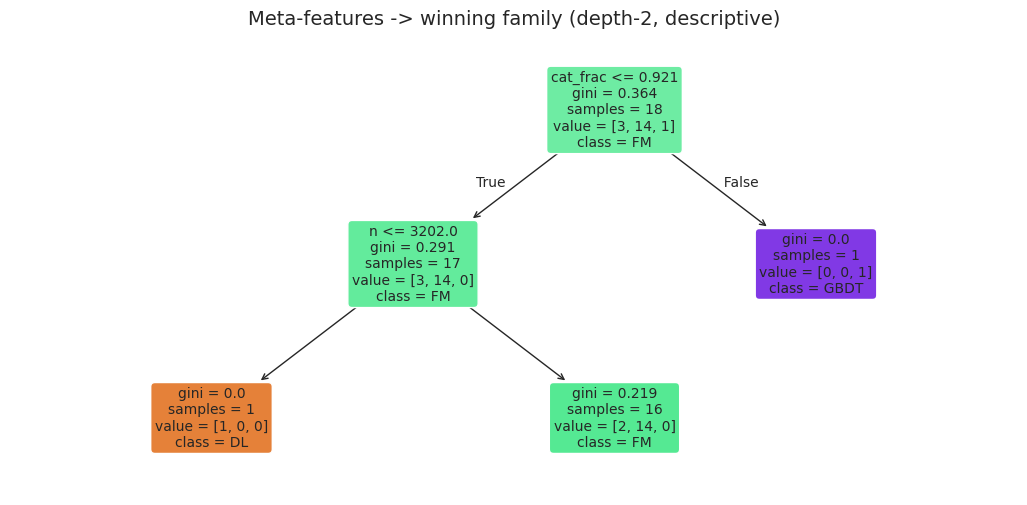

In [4]:
from sklearn.tree import plot_tree
clf, txt, acc = winner_decision_tree(W, max_depth=2)
print(txt)
print(f'Train accuracy (DESCRIPTIVE, N={len(W)} — no held-out): {acc:.2f}')

fig, ax = plt.subplots(figsize=(13,6))
plot_tree(clf, feature_names=['n','n_feat','imbalance','cat_frac'],
          class_names=clf.classes_, filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Meta-features -> winning family (depth-2, descriptive)')
plt.savefig('../results/figures/winner_decision_tree.png'); plt.show()

**Reading.** The tree recovers the story cleanly: **small + low-dimensional ->
TabPFN**; **larger + low-dimensional -> GBDT**; **high-dimensional numerical ->
deep learning**; **high-dimensional with categoricals -> back to TabPFN/GBDT**.
That is exactly the set of reversals from notebook 07, now expressed as
splitting rules. It is descriptive at N=18, but it gives the flowchart in
notebook 09 a data-grounded skeleton instead of intuition.